# 📊 Superstore Sales — Complete EDA Project

**Tools:** Pandas • NumPy • Matplotlib • Seaborn

This project performs a complete Exploratory Data Analysis (EDA) of the provided **Sample - Superstore.xls** dataset.

### Analysis Areas
- Data loading and quality checks
- Missing values and duplicates
- Descriptive statistics
- Sales, Profit, Quantity and Order KPIs
- Category and Sub-Category analysis
- Region, State and Segment analysis
- Time-series trends
- Top/bottom products
- Loss-making analysis
- Correlation and outliers
- Customer analysis
- Business insights
- Actionable recommendations


In [7]:
# 1. Install/verify the Excel reader needed for .xls files
# Run this cell if xlrd is not already installed.
import sys, subprocess, importlib.util

if importlib.util.find_spec("xlrd") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xlrd>=2.0.1"])

print("xlrd is ready.")


xlrd is ready.


In [8]:
# 2. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Libraries imported successfully.")


Pandas: 3.0.1
NumPy: 2.4.3
Libraries imported successfully.


In [10]:
# 3. Load Dataset
FILE_PATH = r"D:\PowerBI\Superstore Sales Datasets\Sample - Superstore.xls"

df = pd.read_excel(FILE_PATH, engine="xlrd")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Rows: 10,194
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2020-103800,2020-01-03,2020-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2020-141817,2020-01-05,2020-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [11]:
# 4. Dataset Overview
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDuplicate Rows:", df.duplicated().sum())


Shape: (10194, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:


,Data Type
Row ID,int64
Order ID,str
Order Date,datetime64[us]
Ship Date,datetime64[us]
Ship Mode,str
Customer ID,str
Customer Name,str
Segment,str
Country/Region,str
City,str



Duplicate Rows: 0


In [12]:
# 5. Missing Values
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

display(missing[missing["Missing Count"] > 0])


,Missing Count,Missing %


In [13]:
# 6. Data Cleaning & Date Features
df = df.drop_duplicates().copy()

for col in ["Order Date", "Ship Date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

if "Order Date" in df.columns:
    df["Order Year"] = df["Order Date"].dt.year
    df["Order Month"] = df["Order Date"].dt.month
    df["Order Month Name"] = df["Order Date"].dt.strftime("%b")
    df["Order Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (10194, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter
0,1,US-2020-103800,2020-01-03,2020-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2020,1,Jan,2020Q1
1,2,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2020,1,Jan,2020Q1
2,3,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2020,1,Jan,2020Q1
3,4,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2020,1,Jan,2020Q1
4,5,US-2020-141817,2020-01-05,2020-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2020,1,Jan,2020Q1


## 7. Descriptive Statistics

In [14]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,10194.0,NaN,NaN,NaN,5097.5,1.0,2549.25,5097.5,7645.75,10194.0,2942.898656
Order ID,10194,5111,US-2023-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10194,NaN,NaN,NaN,2022-04-29 16:37:51.453796,2020-01-03 00:00:00,2021-05-14 00:00:00,2022-06-25 00:00:00,2023-05-14 00:00:00,2023-12-30 00:00:00,NaN
Ship Date,10194,NaN,NaN,NaN,2022-05-03 15:41:38.175397,2020-01-07 00:00:00,2021-05-19 00:00:00,2022-06-28 00:00:00,2023-05-18 00:00:00,2024-01-05 00:00:00,NaN
Ship Mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10194,804,WB-21850,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,10194,800,William Brown,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,10194,3,Consumer,5281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. KPI Analysis

In [15]:
kpis = {}

if "Sales" in df.columns:
    kpis["Total Sales"] = df["Sales"].sum()
if "Profit" in df.columns:
    kpis["Total Profit"] = df["Profit"].sum()
if "Quantity" in df.columns:
    kpis["Total Quantity"] = df["Quantity"].sum()
if "Order ID" in df.columns:
    kpis["Unique Orders"] = df["Order ID"].nunique()
if "Customer ID" in df.columns:
    kpis["Unique Customers"] = df["Customer ID"].nunique()
if "Sales" in df.columns and "Profit" in df.columns:
    kpis["Profit Margin %"] = df["Profit"].sum() / df["Sales"].sum() * 100

kpi_df = pd.DataFrame(kpis.items(), columns=["KPI", "Value"])
display(kpi_df)


,KPI,Value
0,Total Sales,2.326534e+06
1,Total Profit,2.922968e+05
2,Total Quantity,3.865400e+04
3,Unique Orders,5.111000e+03
4,Unique Customers,8.040000e+02
5,Profit Margin %,1.256361e+01


## 9. Sales Distribution

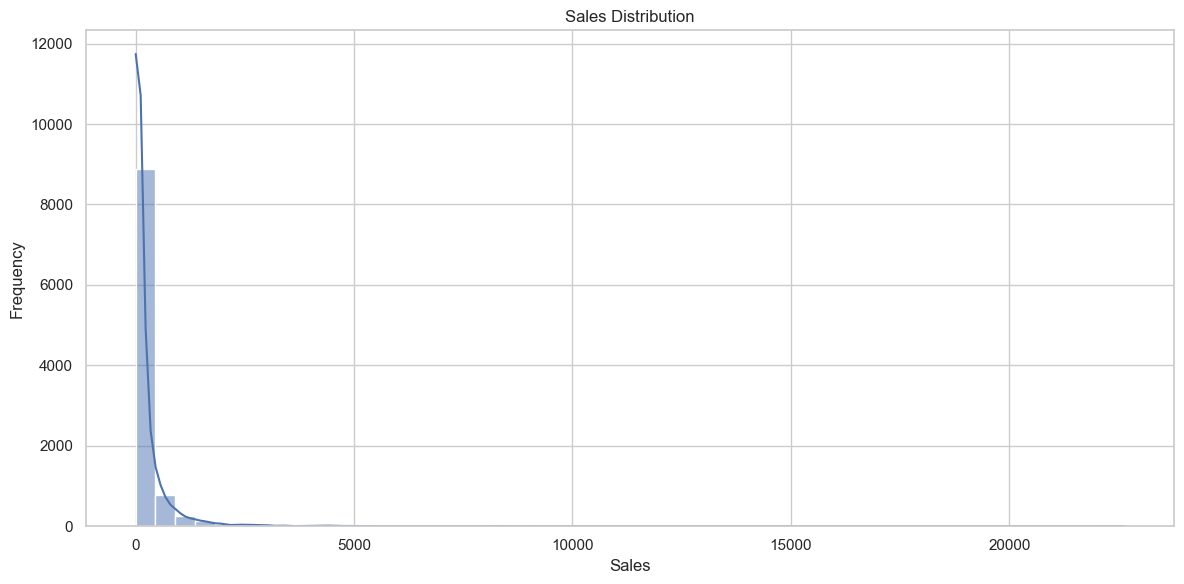

In [16]:
plt.figure(figsize=(12,6))
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 10. Profit Distribution

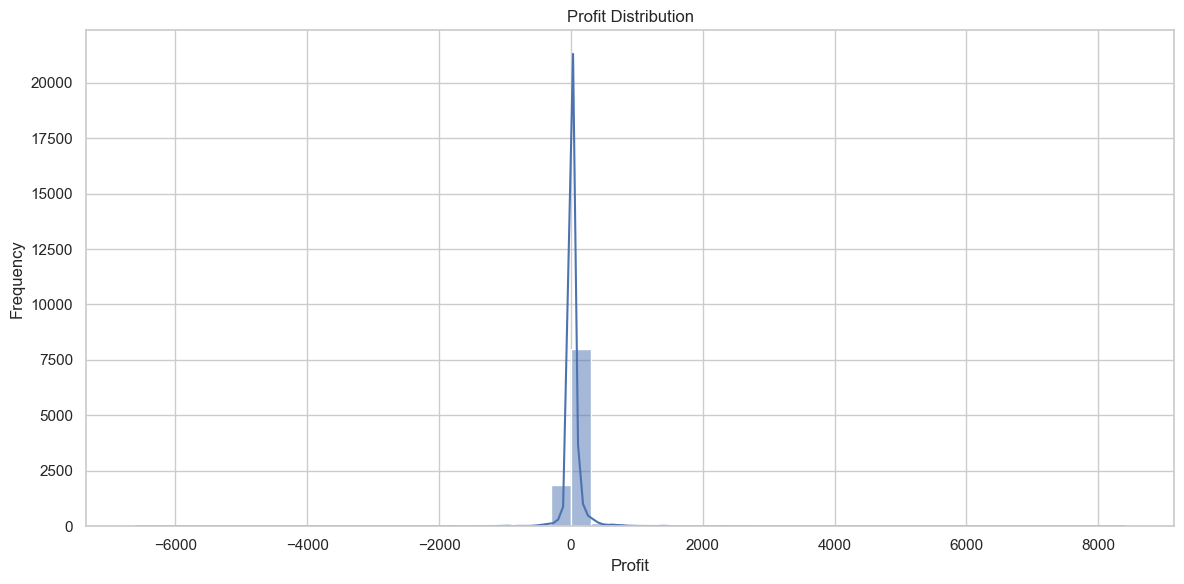

In [17]:
plt.figure(figsize=(12,6))
sns.histplot(df["Profit"], bins=50, kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 11. Category Analysis

,Sales,Profit,Quantity
Category,,,
Technology,839893.2790,146543.3756,7017
Furniture,754747.7613,19729.9956,8369
Office Supplies,731893.3140,126023.4434,23268


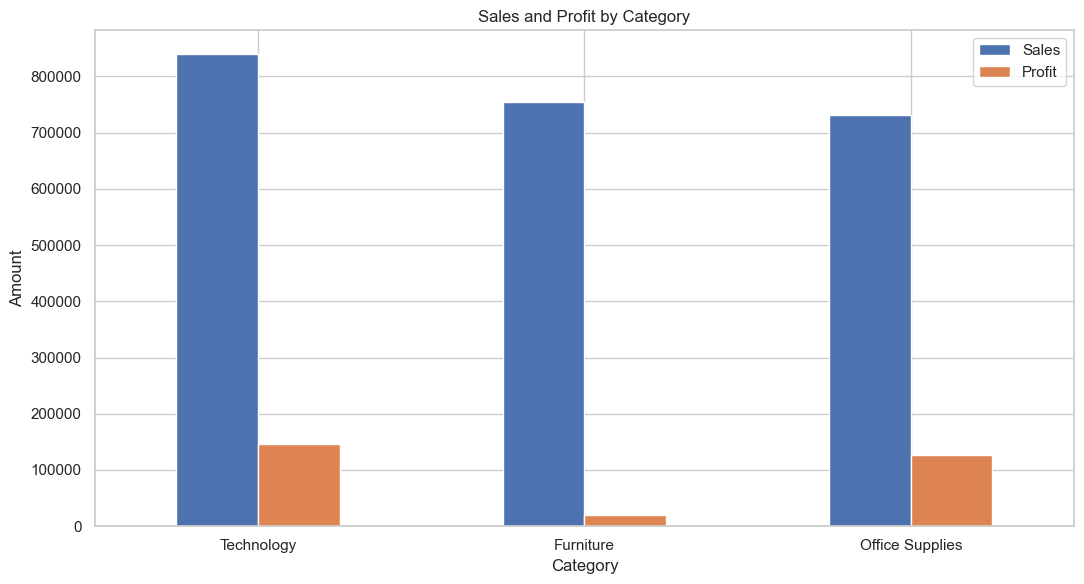

In [18]:
category = df.groupby("Category").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Quantity=("Quantity","sum")
).sort_values("Sales", ascending=False)

display(category)

category[["Sales","Profit"]].plot(kind="bar", figsize=(11,6))
plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Sub-Category Analysis

,Sales,Profit,Quantity
Sub-Category,,,
Chairs,335768.2490,27223.5323,2431
Phones,331842.6400,45050.8265,3357
Storage,224644.5540,21285.1115,3191
Tables,208020.1820,-17753.2061,1261
Binders,207354.8810,31426.1003,6071
Machines,189925.0310,3461.9769,442
Accessories,167380.3180,41936.6357,2976
Copiers,150745.2900,56093.9365,242
Bookcases,115361.2043,-3632.0736,878


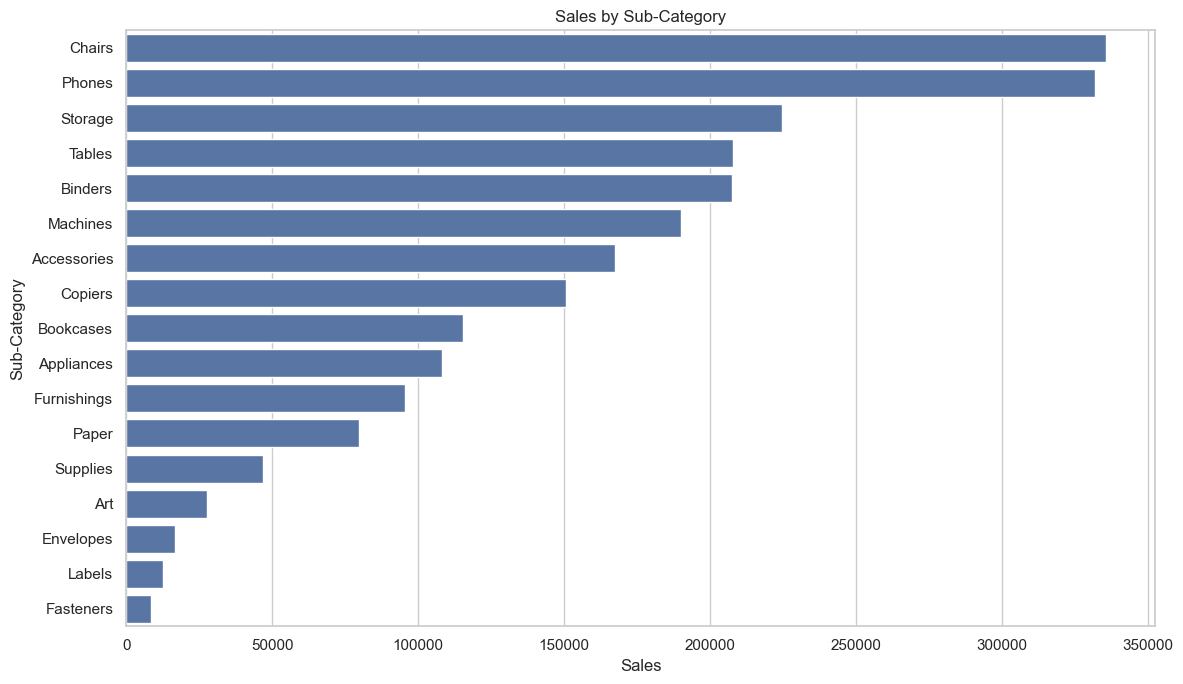

In [19]:
subcat = df.groupby("Sub-Category").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Quantity=("Quantity","sum")
).sort_values("Sales", ascending=False)

display(subcat)

plt.figure(figsize=(12,7))
sns.barplot(data=subcat.reset_index(), y="Sub-Category", x="Sales")
plt.title("Sales by Sub-Category")
plt.tight_layout()
plt.show()


,Sales,Profit,Quantity
Sub-Category,,,
Tables,208020.1820,-17753.2061,1261
Bookcases,115361.2043,-3632.0736,878
Supplies,46725.4980,-1171.3945,653
Fasteners,8532.2400,2428.6358,980
Machines,189925.0310,3461.9769,442
Labels,12695.0420,5572.7780,1410
Art,27659.0140,6653.1962,3092
Envelopes,16528.3620,6988.0247,914
Furnishings,95598.1260,13891.7430,3799


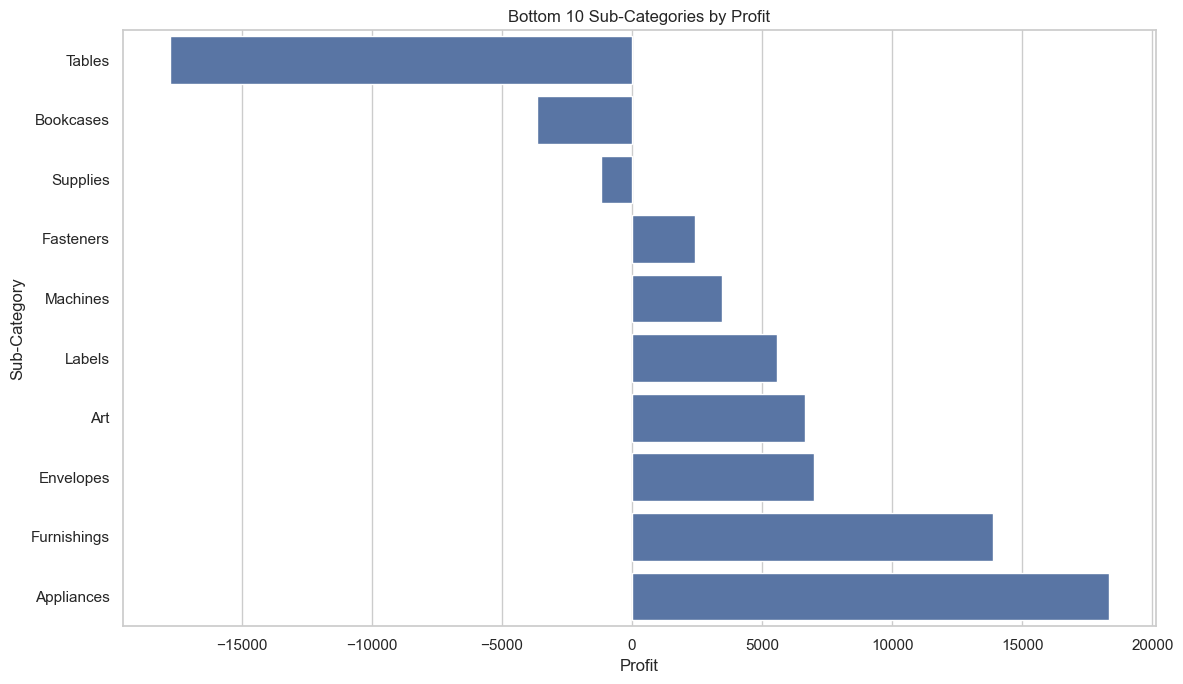

In [20]:
# Bottom sub-categories by profit
bottom_subcat = subcat.sort_values("Profit").head(10)
display(bottom_subcat)

plt.figure(figsize=(12,7))
sns.barplot(data=bottom_subcat.reset_index(), y="Sub-Category", x="Profit")
plt.title("Bottom 10 Sub-Categories by Profit")
plt.tight_layout()
plt.show()


## 13. Region Analysis

,Sales,Profit,Orders
Region,,,
West,739813.6085,110798.8170,1635
East,691828.1680,94883.2603,1475
Central,503170.6728,39865.3070,1179
South,391721.9050,46749.4303,822


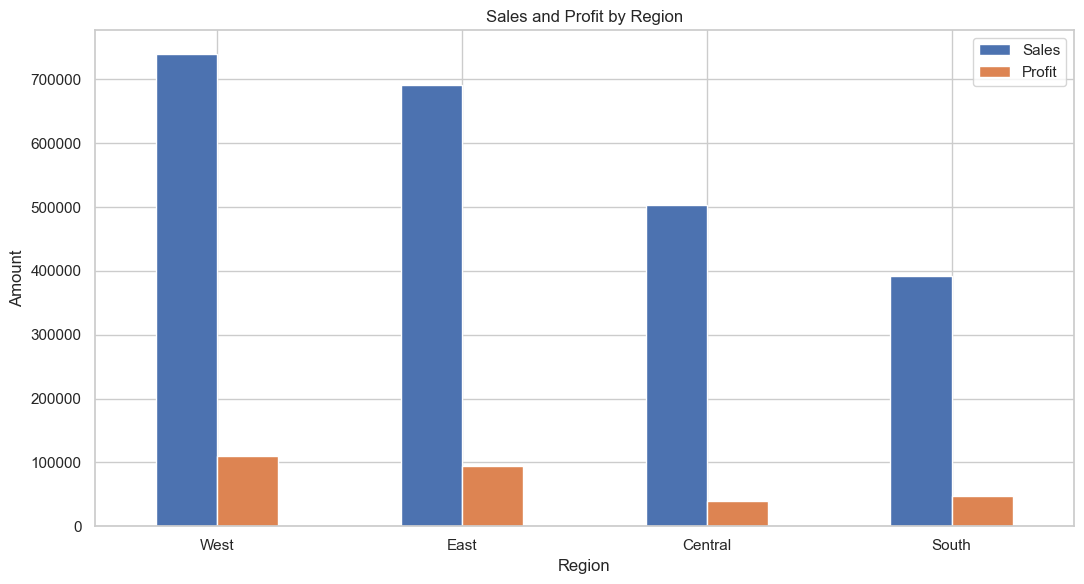

In [21]:
region = df.groupby("Region").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order ID","nunique")
).sort_values("Sales", ascending=False)

display(region)

region[["Sales","Profit"]].plot(kind="bar", figsize=(11,6))
plt.title("Sales and Profit by Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 14. State Analysis

Top 15 States by Sales


,Sales,Profit
State/Province,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Texas,170188.0458,-25729.3563
Washington,138641.2700,33402.6517
Pennsylvania,116511.9140,-15559.9603
Florida,89473.7080,-3399.3017
Illinois,80166.1010,-12607.8870
Ohio,78258.1360,-16971.3766
Michigan,76269.6140,24463.1876


Bottom 15 States by Profit


,Sales,Profit
State/Province,,
Texas,170188.0458,-25729.3563
Ohio,78258.1360,-16971.3766
Pennsylvania,116511.9140,-15559.9603
Illinois,80166.1010,-12607.8870
North Carolina,55603.1640,-7490.9122
Colorado,32108.1180,-6527.8579
Tennessee,30661.8730,-5341.6936
Arizona,35282.0010,-3427.9246
Florida,89473.7080,-3399.3017


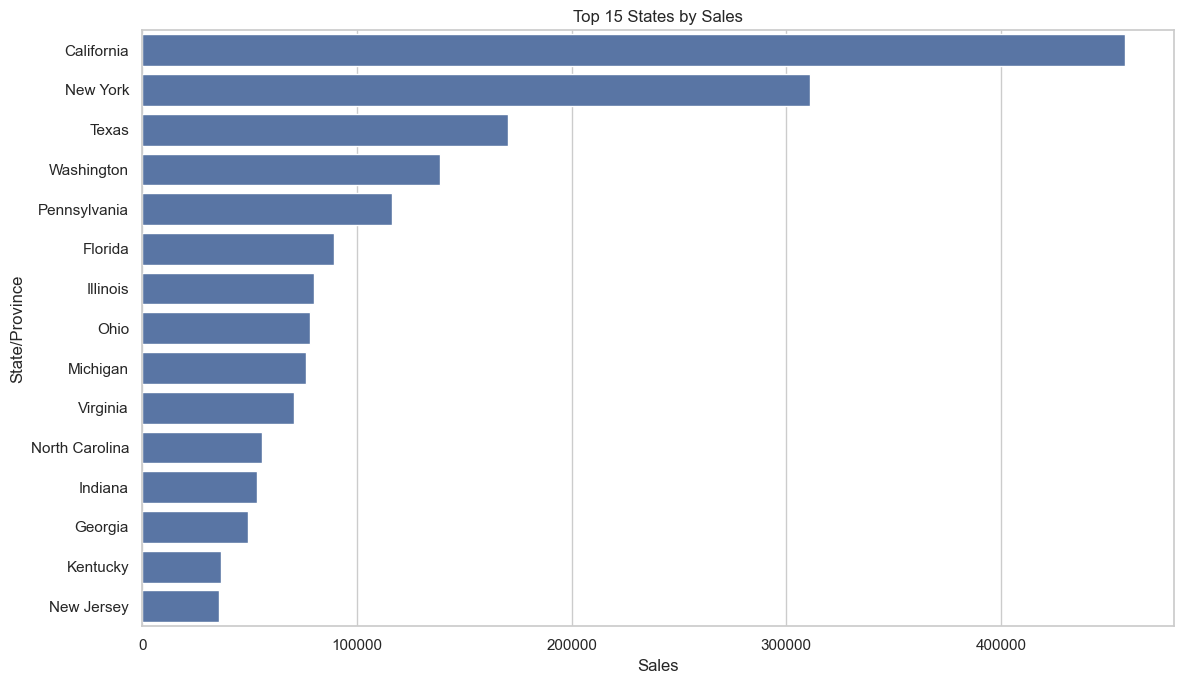

In [29]:
state = df.groupby('State/Province').agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum")
)

top_states = state.sort_values("Sales", ascending=False).head(15)
loss_states = state.sort_values("Profit").head(15)

print("Top 15 States by Sales")
display(top_states)

print("Bottom 15 States by Profit")
display(loss_states)

plt.figure(figsize=(12,7))
sns.barplot(data=top_states.reset_index(), y="State/Province", x="Sales")
plt.title("Top 15 States by Sales")
plt.tight_layout()
plt.show()


## 15. Customer Segment Analysis

,Sales,Profit,Orders
Segment,,,
Consumer,1.170660e+06,136371.4463,2628
Corporate,7.158061e+05,94249.6400,1552
Home Office,4.400684e+05,61675.7283,931


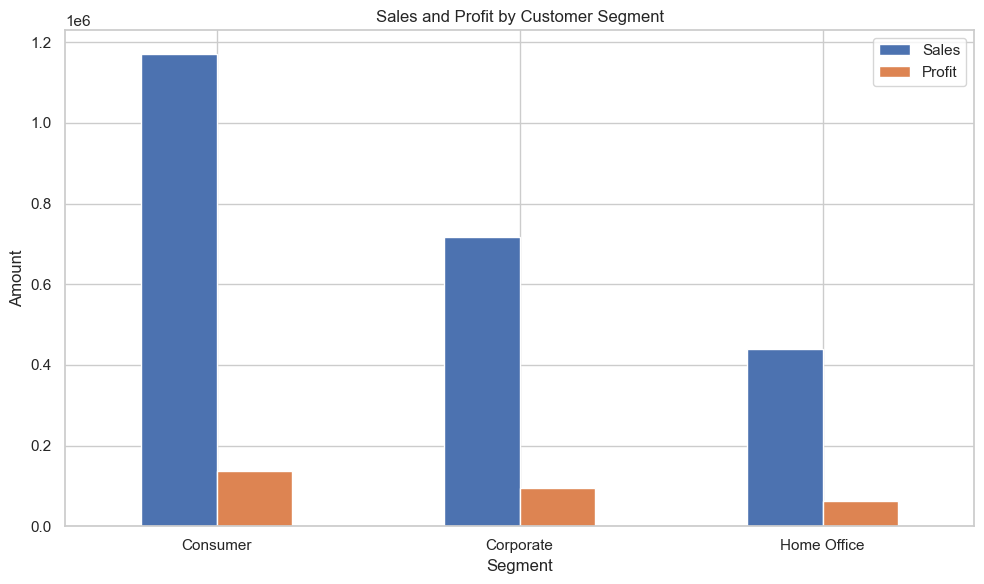

In [30]:
segment = df.groupby("Segment").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order ID","nunique")
).sort_values("Sales", ascending=False)

display(segment)

segment[["Sales","Profit"]].plot(kind="bar", figsize=(10,6))
plt.title("Sales and Profit by Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 16. Time-Series Analysis

,Sales,Profit
Order Date,,
2023-01-01,44259.2140,7231.6391
2023-02-01,20301.1334,1613.8720
2023-03-01,60728.4808,15013.0910
2023-04-01,36779.0361,957.5300
2023-05-01,45155.4822,6299.8072
2023-06-01,53056.0777,8246.5707
2023-07-01,45989.4960,7006.5012
2023-08-01,64129.7580,9488.0722
2023-09-01,88064.5320,11050.8024


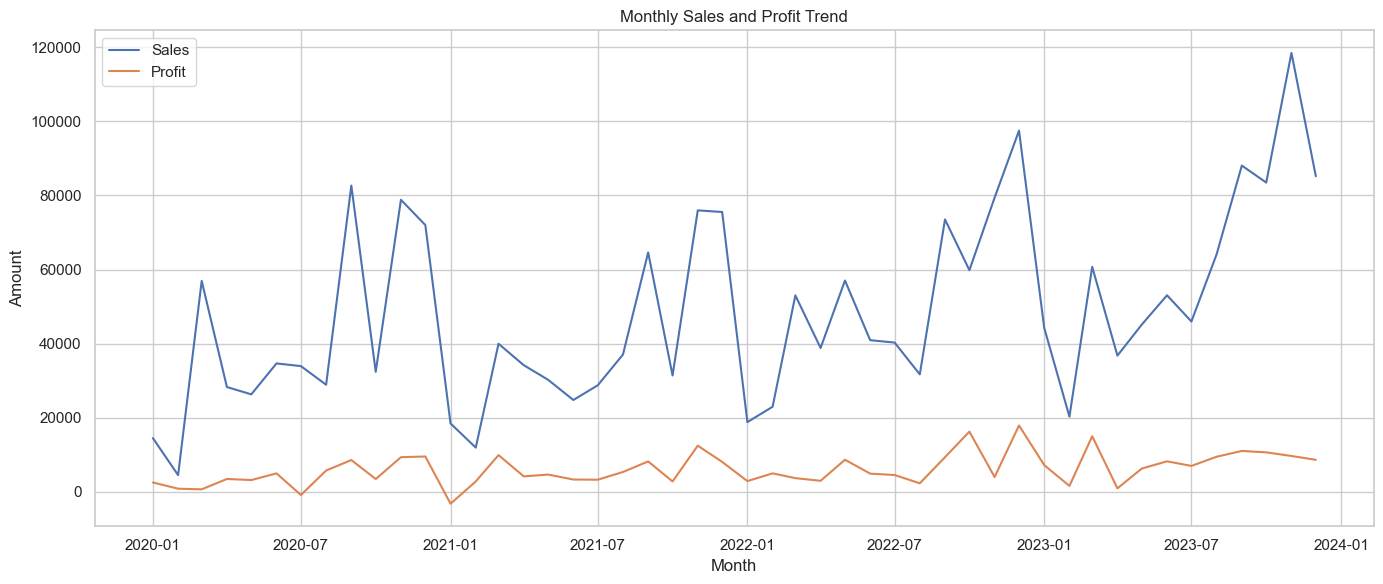

In [31]:
monthly = df.set_index("Order Date").resample("MS").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum")
)

display(monthly.tail(12))

plt.figure(figsize=(14,6))
plt.plot(monthly.index, monthly["Sales"], label="Sales")
plt.plot(monthly.index, monthly["Profit"], label="Profit")
plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()


,Sales,Profit,Orders
Order Year,,,
2020,494040.2121,51684.2957,995
2021,472993.0310,62020.9695,1053
2022,613933.5800,82665.2018,1340
2023,745567.5312,95926.3476,1723


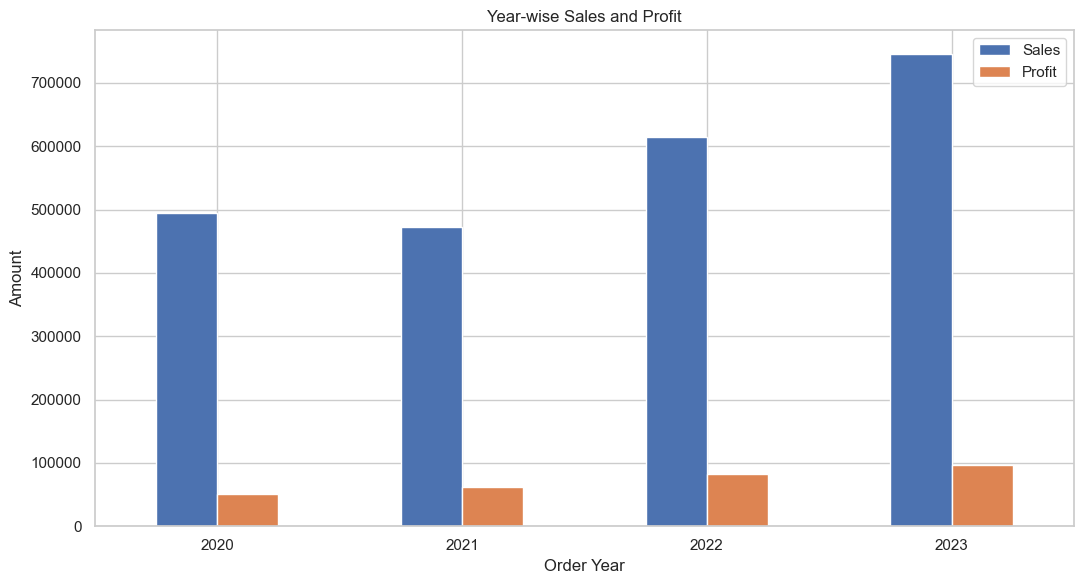

In [32]:
yearly = df.groupby("Order Year").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order ID","nunique")
)

display(yearly)

yearly[["Sales","Profit"]].plot(kind="bar", figsize=(11,6))
plt.title("Year-wise Sales and Profit")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 17. Top & Bottom Products

In [33]:
products = df.groupby("Product Name").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order ID","nunique")
)

print("Top 10 Products by Sales")
display(products.sort_values("Sales", ascending=False).head(10))

print("Top 10 Products by Profit")
display(products.sort_values("Profit", ascending=False).head(10))

print("Bottom 10 Products by Profit")
display(products.sort_values("Profit").head(10))


Top 10 Products by Sales


,Sales,Profit,Orders
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,5
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,10
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,1
HON 5400 Series Task Chairs for Big and Tall,21870.576,3.410605e-13,8
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,11
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,9
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,8
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,3
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,6


Top 10 Products by Profit


,Sales,Profit,Orders
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,5
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,10
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,8
Canon PC1060 Personal Laser Copier,11619.834,4570.9347,4
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,3
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,2
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,2
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,7
Ibico EPK-21 Electric Binding System,15875.916,3345.2823,3


Bottom 10 Products by Profit


,Sales,Profit,Orders
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,3
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,4
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,1
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,5
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,7
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,6
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,1
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,6
Balt Solid Wood Round Tables,6518.754,-1201.0581,4


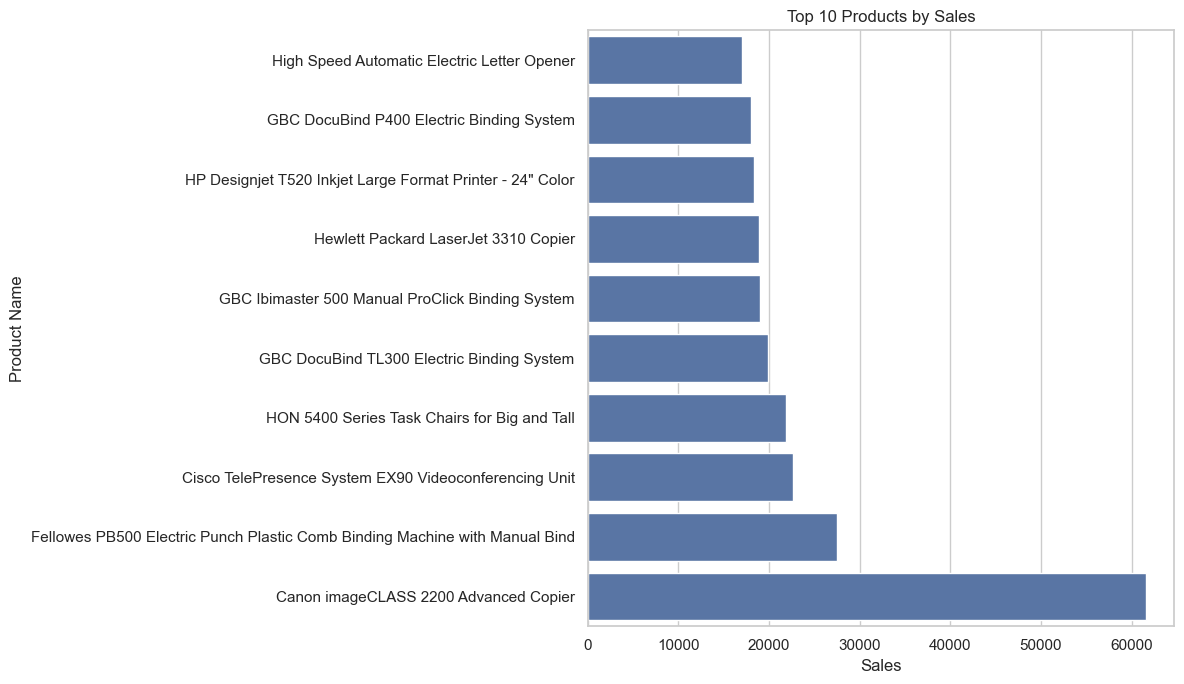

In [34]:
top_products = products.sort_values("Sales", ascending=False).head(10).sort_values("Sales")

plt.figure(figsize=(12,7))
sns.barplot(data=top_products.reset_index(), y="Product Name", x="Sales")
plt.title("Top 10 Products by Sales")
plt.tight_layout()
plt.show()


## 18. Loss-Making Analysis

In [35]:
loss_df = df[df["Profit"] < 0].copy()

print(f"Loss-making transaction rows: {len(loss_df):,}")
print(f"Loss-making sales value: {loss_df['Sales'].sum():,.2f}")
print(f"Total loss: {loss_df['Profit'].sum():,.2f}")
print(f"Loss-making row %: {len(loss_df)/len(df)*100:.2f}%")

loss_subcat = loss_df.groupby("Sub-Category").agg(
    Loss=("Profit","sum"),
    Sales=("Sales","sum")
).sort_values("Loss")

display(loss_subcat.head(10))


Loss-making transaction rows: 1,901
Loss-making sales value: 472,248.76
Total loss: -157,038.93
Loss-making row %: 18.65%


,Loss,Sales
Sub-Category,,
Binders,-38563.4860,36200.5010
Tables,-32503.6583,105699.3760
Machines,-30118.6682,72456.2530
Bookcases,-12349.8096,48217.3288
Chairs,-10135.0373,93460.1680
Appliances,-8629.6412,3382.5340
Phones,-7530.6235,35797.8400
Furnishings,-6686.6785,13293.4840
Storage,-6480.2220,38429.1440


## 19. Sales vs Profit Relationship

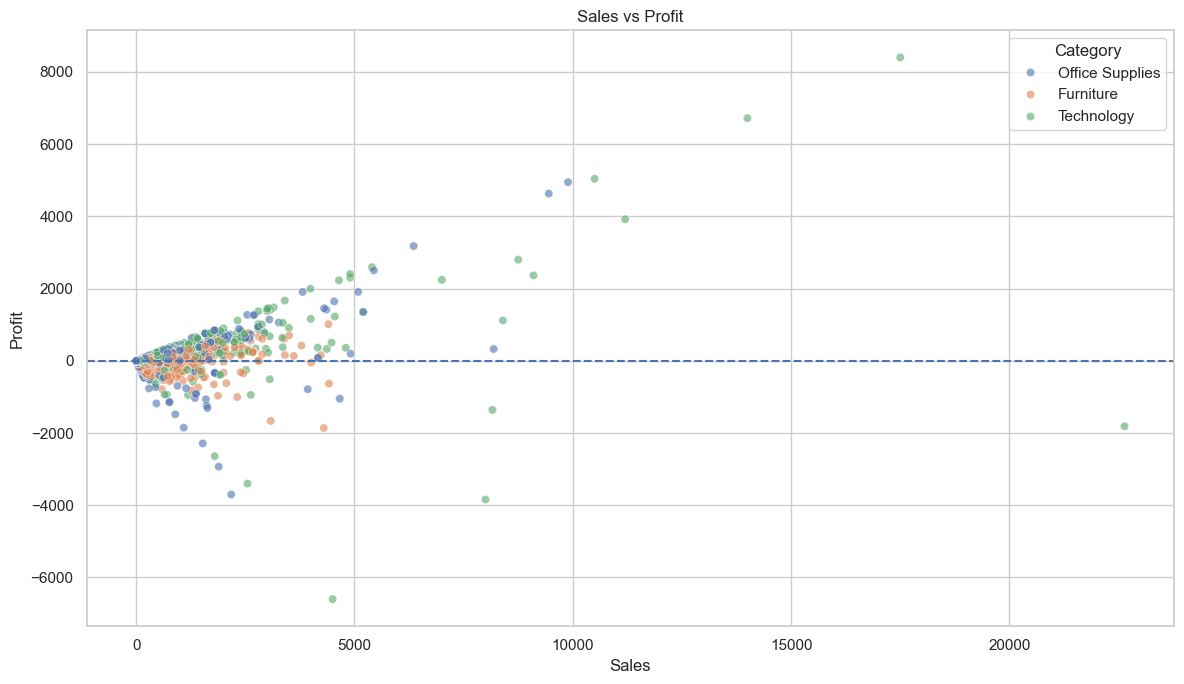

In [36]:
plt.figure(figsize=(12,7))
sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category",
    alpha=0.6
)
plt.axhline(0, linestyle="--")
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


## 20. Correlation Heatmap

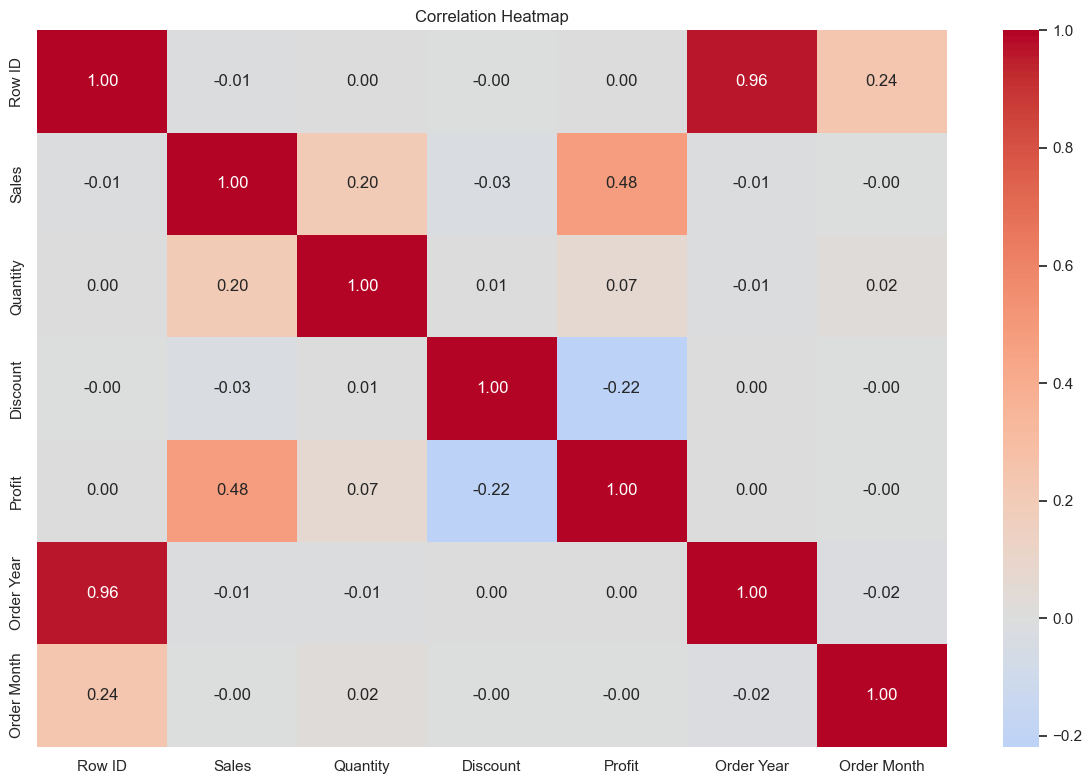

In [37]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 21. Outlier Detection using IQR

In [38]:
def iqr_summary(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[column] < lower) | (data[column] > upper)
    return {
        "Column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(mask.sum()),
        "Outlier %": round(mask.mean()*100, 2)
    }

outliers = pd.DataFrame([
    iqr_summary(df, c) for c in ["Sales","Profit","Quantity"]
])

display(outliers)


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Sales,17.2200,209.500000,192.280000,-271.200000,497.920000,1183,11.60
1,Profit,1.7608,29.297925,27.537125,-39.544887,70.603612,1913,18.77
2,Quantity,2.0000,5.000000,3.000000,-2.500000,9.500000,175,1.72


## 22. Customer Analysis

In [39]:
customer = df.groupby("Customer ID").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order ID","nunique")
)

print("Top 10 Customers by Sales")
display(customer.sort_values("Sales", ascending=False).head(10))

print("Top 10 Customers by Profit")
display(customer.sort_values("Profit", ascending=False).head(10))


Top 10 Customers by Sales


,Sales,Profit,Orders
Customer ID,,,
SM-20320,25043.050,-1980.7393,5
TC-20980,19052.218,8981.3239,5
RB-19360,15117.339,6976.0959,6
TA-21385,14595.620,4703.7883,4
AB-10105,14473.571,5444.8055,10
KL-16645,14175.229,806.8550,12
SC-20095,14142.334,5757.4119,9
HL-15040,12873.298,5622.4292,6
SE-20110,12209.438,2650.6769,11


Top 10 Customers by Profit


,Sales,Profit,Orders
Customer ID,,,
TC-20980,19052.218,8981.3239,5
RB-19360,15117.339,6976.0959,6
SC-20095,14142.334,5757.4119,9
HL-15040,12873.298,5622.4292,6
AB-10105,14473.571,5444.8055,10
TA-21385,14595.620,4703.7883,4
CM-12385,8954.020,3899.8904,4
KD-16495,8181.256,3038.6254,12
AR-10540,6608.448,2884.6208,6


## 23. Automated Business Insights

In [40]:
insights = []

best_category = category["Sales"].idxmax()
best_category_sales = category["Sales"].max()
insights.append(f"Highest-sales category: {best_category} with {best_category_sales:,.2f} sales.")

best_profit_category = category["Profit"].idxmax()
worst_profit_category = category["Profit"].idxmin()
insights.append(f"Most profitable category: {best_profit_category}.")
insights.append(f"Weakest category by total profit: {worst_profit_category}.")

best_region = region["Profit"].idxmax()
worst_region = region["Profit"].idxmin()
insights.append(f"Most profitable region: {best_region}.")
insights.append(f"Weakest region by profit: {worst_region}.")

best_product = products["Profit"].idxmax()
worst_product = products["Profit"].idxmin()
insights.append(f"Highest-profit product: {best_product}.")
insights.append(f"Lowest-profit product: {worst_product}.")

loss_rate = (df["Profit"] < 0).mean() * 100
insights.append(f"{loss_rate:.2f}% of transaction rows are loss-making.")

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")


1. Highest-sales category: Technology with 839,893.28 sales.
2. Most profitable category: Technology.
3. Weakest category by total profit: Furniture.
4. Most profitable region: West.
5. Weakest region by profit: Central.
6. Highest-profit product: Canon imageCLASS 2200 Advanced Copier.
7. Lowest-profit product: Cubify CubeX 3D Printer Double Head Print.
8. 18.65% of transaction rows are loss-making.


## 24. Business Recommendations

In [41]:
recommendations = [
    "Prioritize categories and products that generate both high Sales and high Profit.",
    "Investigate loss-making sub-categories and products before increasing their sales volume.",
    "Review discounting, pricing and shipping economics for high-sales but low-profit products.",
    "Focus customer retention and cross-selling on high-value and high-profit customers.",
    "Use monthly Sales and Profit trends to improve inventory, staffing and campaign planning.",
    "Investigate weak-profit regions/states for pricing, shipping-cost and product-mix issues.",
    "Track Sales, Profit, Profit Margin, Orders, Customers and loss rate in a recurring dashboard.",
    "Monitor outliers separately because unusually large transactions can materially affect aggregate KPIs."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")


1. Prioritize categories and products that generate both high Sales and high Profit.
2. Investigate loss-making sub-categories and products before increasing their sales volume.
3. Review discounting, pricing and shipping economics for high-sales but low-profit products.
4. Focus customer retention and cross-selling on high-value and high-profit customers.
5. Use monthly Sales and Profit trends to improve inventory, staffing and campaign planning.
6. Investigate weak-profit regions/states for pricing, shipping-cost and product-mix issues.
7. Track Sales, Profit, Profit Margin, Orders, Customers and loss rate in a recurring dashboard.
8. Monitor outliers separately because unusually large transactions can materially affect aggregate KPIs.


## 25. Final Conclusion

This EDA converts the raw Superstore dataset into business-focused insights.

### Recommended next project
Build a **Power BI Superstore Sales & Profitability Dashboard** with:
- Executive KPI Summary
- Sales & Profit Trend
- Category/Sub-Category Performance
- Region & State Analysis
- Customer Segment Analysis
- Top/Bottom Products
- Loss-Making Product Analysis

The Python EDA can serve as the analytical foundation for the dashboard and interview/project portfolio.


In [42]:
# 26. Export Cleaned Dataset
df.to_csv("Superstore_Cleaned.csv", index=False)
print("Cleaned dataset exported as Superstore_Cleaned.csv")


Cleaned dataset exported as Superstore_Cleaned.csv
